# Predicción de series temporales con Keras `SimpleRNN`

En este notebook, mostramos la construcción de una simple red neuronal recurrente (RNN) usando Keras.

Generaremos algunos datos de series temporales sintéticas multiplicando dos señales periódicas/sinusoidales y añadiendo algo de estocasticidad (ruido gaussiano). A continuación, tomaremos una pequeña fracción de los datos y entrenaremos un modelo RNN simple con ellos e intentaremos predecir el resto de los datos y ver cómo coinciden las predicciones con la verdad.

## Sobre redes neuronales recurrentes (RNN)

Las RNN son RRNN especializadas en series temporales y en tratamiento de texto. Mediante sus capas ocultas son capaces de retener información sobre lo acontecido hasta el momento.

Keras dispone de muchas de las neuronas más habituales empleadas en este dominio ya codificadas: https://keras.io/api/layers/recurrent_layers/

#### LSTM: Long Short Memory Layer. 
Son capas capaces de trabajar con secuencias de datos. Muy útiles para vídeo o speech recognition. Las neuronas tienen una memoria de los valores anteriores.

![LSTM](https://upload.wikimedia.org/wikipedia/commons/thumb/9/93/LSTM_Cell.svg/330px-LSTM_Cell.svg.png){width=50%}

Tenéis algo más de detalle en https://colah.github.io/posts/2015-08-Understanding-LSTMs/

In [1]:
%pip install tensorflow keras

  Using cached ml_dtypes-0.3.2-cp311-cp311-macosx_10_9_universal2.whl.metadata (20 kB)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
Using cached ml_dtypes-0.3.2-cp311-cp311-macosx_10_9_universal2.whl (389 kB)
Using cached tensorboard-2.16.2-py3-none-any.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.6 MB/s  0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.15.2
    Uninstalling tensorboard-2.15.2:
      Successfully uninstalled tensorboard-2.15.2
  Attempting uninstall: kerasm╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tensorboard]
    Found existing installation: keras 2.15.0━━━━━━━━━━━━━━━━━ 1/3 [tensorboard]
    Uninstalling keras-2.15.0:m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tensorboard]
      Successfully uninstalled keras-2.15.0╸━━━━━━━━━━━━━ 2/3 [

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import Callback

In [3]:
# Total time points
N = 3004

np.random.seed(0)
t=np.arange(0,N)
x=(2*np.sin(0.02*t)*np.sin(0.003*t))+0.5*np.random.normal(size=N)

df = pd.DataFrame(x, columns=['Data'])
df.head()

,Data
0,0.882026
1,0.200199
2,0.489849
3,1.121526
4,0.935697


Esta tendencia no va a ser sencilla de conseguir. En general bien, pero hay algunas partes raras que no siguen la tendencia, debido al ruido gausiano.

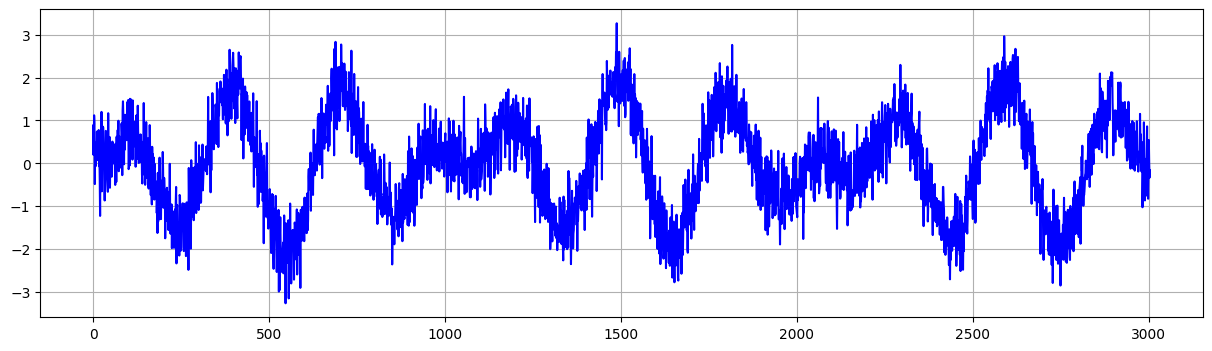

In [4]:
plt.figure(figsize=(15,4))
plt.plot(df,c='blue')
plt.grid(True);

### Dividir los valores en entrenamiento y prueba

Así pues, tomamos sólo el 25% de los datos como muestras de entrenamiento y reservamos el resto de los datos para las pruebas. 

Observando el gráfico de la serie temporal, pensamos que **no es fácil que un modelo estándar consiga predicciones de tendencia correctas**.

In [5]:
values = df.values

# Time point to partition train/test splits.
# 25% of data (754) for TRAIN and the rest for test
Tp = 754   

train, test = values[0:Tp ,:], values[Tp:N,:]

In [6]:
print("Tamaño train:", train.shape)
print("Tamaño test:", test.shape)

Tamaño train: (754, 1)
Tamaño test: (2250, 1)


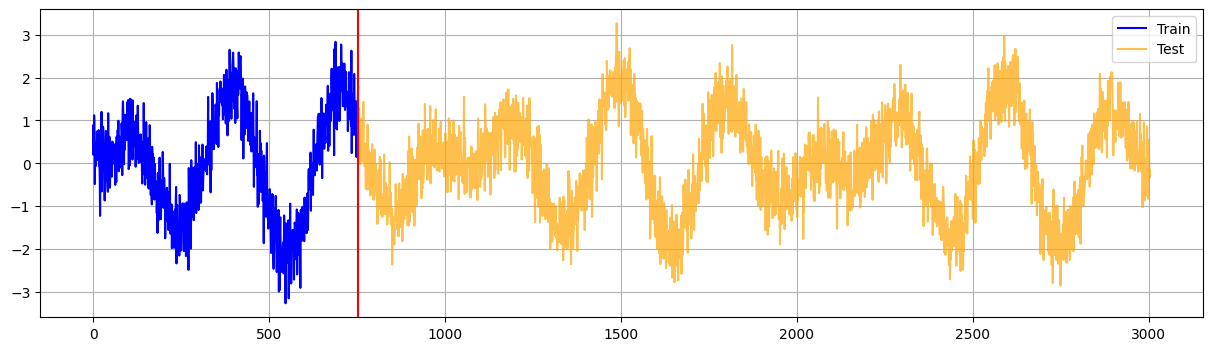

In [7]:
index = df.index.values
plt.figure(figsize=(15,4))
plt.plot(index[0:Tp],train,c='blue')
plt.plot(index[Tp:N],test,c='orange',alpha=0.7)
plt.legend(['Train','Test'])
plt.axvline(Tp, c="r")
plt.grid(True);

### Paso (o _embedding_)
El modelo RNN requiere un valor de paso que contenga $n$ número de elementos como secuencia de entrada.

Supongamos x = {1,2,3,4,5,6,7,8,9,10}

para `paso=1`, la entrada $x$ y su predicción $y$ se convierten en:

| x | y |
|---|---|
| 1 | 2 |
| 2 | 3 |
| 3 | 4 |
| ...  | ...  |
| 9 | 10 |

para `paso=3`, $x$ e $y$ contienen:

| x | y |
|---|---|
| 1,2,3 | 4 |
| 2,3,4 | 5 |
| 3,4,5 | 6 |
| ...  | ...  |
| 7,8,9 | 10 |

Aquí, elegimos `paso=4`. En RNN más complejas y en particular para el procesamiento de texto, esto también se llama _embedding size_.

Básicamente los pasos son el número de lags necesarios para realizar las predicciones. Escogemos 4 lags.

In [8]:
df2 = df.copy() # Por si las moscas
emb_size = 4 # Pasos

for i in range(1, emb_size+1):
    df2['lag' + str(i)] = df2['Data'].shift(i)

In [9]:
df2.dropna(inplace=True)
df2.reset_index(drop=True, inplace=True)
df2

,Data,lag1,lag2,lag3,lag4
0,0.935697,1.121526,0.489849,0.200199,0.882026
1,-0.485644,0.935697,1.121526,0.489849,0.200199
2,0.479354,-0.485644,0.935697,1.121526,0.489849
3,-0.069818,0.479354,-0.485644,0.935697,1.121526
4,-0.043963,-0.069818,0.479354,-0.485644,0.935697
...,...,...,...,...,...
2995,-0.277347,-0.828811,-0.303959,-0.646398,0.862306
2996,0.545401,-0.277347,-0.828811,-0.303959,-0.646398
2997,0.019247,0.545401,-0.277347,-0.828811,-0.303959
2998,-0.335919,0.019247,0.545401,-0.277347,-0.828811


In [10]:
values = df2.values

#Volvemos a montar xtrain, xtest...
trainX,trainY = values[0:Tp-emb_size ,1:],values[0:Tp-emb_size ,0],
testX,testY = values[Tp-emb_size:N-emb_size,1:], values[Tp-emb_size:N-emb_size,0]

print("Tamaño datos Train:", trainX.shape)
print("Target en Train:", trainY.shape)
print("Tamaño datos test:", testX.shape)
print("Target en Test:", testY.shape)

Tamaño datos Train: (750, 4)
Target en Train: (750,)
Tamaño datos test: (2250, 4)
Target en Test: (2250,)


750 son los instantes para entrenar (eq a nº muestras).

1 x 4 dimensiones de estos dato, como una imagen. Si fuesen mas variables el 1 seria 2 o 3??

1 es una fila de datos, necesita ese formato

4 los lags para la capa LSTM

In [11]:
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
trainX.shape

(750, 1, 4)

In [12]:
trainX[:3]

array([[[ 1.12152594,  0.48984886,  0.2001986 ,  0.88202617]],

       [[ 0.9356969 ,  1.12152594,  0.48984886,  0.2001986 ]],

       [[-0.48564405,  0.9356969 ,  1.12152594,  0.48984886]]])

Para entrenar el modelo, necesito que los datos tengan la siguiente dimensión:

(750, 1, 4)

- 750: el número total de trozos 
- 1: una fila de datos
- 4: cada trozo tiene cuatro valores

En el caso de una imagen, recordemos con un ejemplo: 

(750, 28, 28)

750 imágenes de resolución 28x28

In [13]:
print("Forma de Train:", trainX.shape,', ',trainY.shape)
print("Forma de Test:", testX.shape,', ',testY.shape)

Forma de Train: (750, 1, 4) ,  (750,)
Forma de Test: (2250, 1, 4) ,  (2250,)


### Modelo en Keras

- 128 neuronas en la capa recurrente (LSTM)
- 32 en la capa densamente conectada
- Una simple neurona como salida.
- activation: ReLu
- learning rate: 0.001

In [14]:
from tensorflow.keras.layers import Dense, LSTM

def rnn_simple(num_units=128, embedding=4, num_dense=32, lr=0.001):
    """
    Construye un modelo sencillo usando capas LSTM

    Arguments:
              num_units: Número de unidades en la capa LSTM
              embedding: Tamaño del embedding (pasos)
              num_dense: Número de neuronas en la capa densa
              lr: Learning rate (RMSprop optimizer)
    Returns:
              Un modelo Keras (arquitectura LSTM -> Densa -> Densa(1))
    """
    model = Sequential()
    # Long short term memory
    # Esto es capa de entrada + capa con 128 neuronas con su función de activacion
    model.add(LSTM(units=num_units, input_shape=(1,embedding), activation="relu"))
    model.add(Dense(num_dense, activation="relu"))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error',
                  optimizer=RMSprop(lr), # adam
                  metrics=['mse'])
    
    return model

In [15]:
model = rnn_simple() # Taking the defaults

2026-05-08 13:08:41.987689: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-08 13:08:41.987718: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-08 13:08:41.987723: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-08 13:08:41.988045: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-08 13:08:41.988429: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. Whe

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,257 (282.25 KB)

 Trainable params: 72,257 (282.25 KB)

 Non-trainable params: 0 (0.00 B)

Callback para ofrecer feedback a las 50 iteraciones. Enseña mensaje si la epoch es múltiplo de 50 y no ha acabado de entrenar.
Cada vez que termina una epoch, Keras llama a on_epoch_end()

In [17]:
class MyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % 50 == 0 and epoch>0:
            print("Epoch number {} done".format(epoch+1))

### Entrenamiento

In [18]:
batch_size=16
num_epochs = 1000

In [19]:
model.fit(trainX,trainY, 
          epochs=num_epochs, 
          batch_size=batch_size, 
          callbacks=[MyCallback()],verbose=0)

2026-05-08 13:08:42.729145: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Epoch number 50 done
Epoch number 100 done
Epoch number 150 done
Epoch number 200 done
Epoch number 250 done
Epoch number 300 done
Epoch number 350 done
Epoch number 400 done
Epoch number 450 done
Epoch number 500 done
Epoch number 550 done
Epoch number 600 done
Epoch number 650 done
Epoch number 700 done
Epoch number 750 done
Epoch number 800 done
Epoch number 850 done
Epoch number 900 done
Epoch number 950 done
Epoch number 1000 done


In [20]:
# Guardamos el modelo
#model.save("my_model.h5")

### Graficamos la pérdida

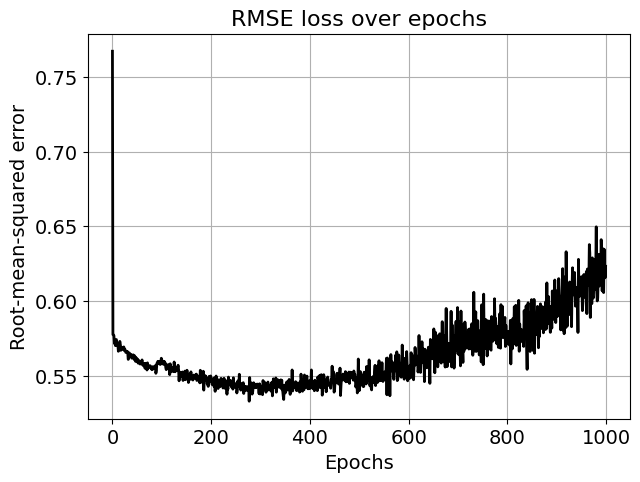

In [21]:
plt.figure(figsize=(7,5))
plt.title("RMSE loss over epochs",fontsize=16)
plt.plot(np.sqrt(model.history.history['loss']),c='k',lw=2)
plt.grid(True)
plt.xlabel("Epochs",fontsize=14)
plt.ylabel("Root-mean-squared error",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14);

### Predicciones

Tened en cuenta que los datos fueron entrenados únicamente con `trainX` y `trainY`. 

In [22]:
trainX

array([[[ 1.12152594,  0.48984886,  0.2001986 ,  0.88202617]],

       [[ 0.9356969 ,  1.12152594,  0.48984886,  0.2001986 ]],

       [[-0.48564405,  0.9356969 ,  1.12152594,  0.48984886]],

       ...,

       [[ 1.3982905 ,  1.18968785,  0.15138804,  1.44883844]],

       [[ 0.15490176,  1.3982905 ,  1.18968785,  0.15138804]],

       [[ 1.18327014,  0.15490176,  1.3982905 ,  1.18968785]]])

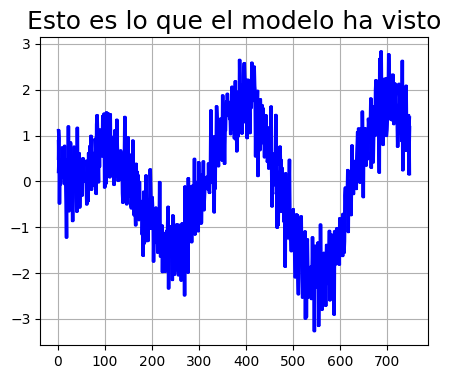

In [23]:
plt.figure(figsize=(5,4))
plt.title("Esto es lo que el modelo ha visto",fontsize=18)
# Saca todos los valores de train, la primera columna
plt.plot(trainX[:,0],c='blue')
plt.grid(True)
plt.show()

In [24]:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
predicted = np.concatenate((trainPredict,testPredict),axis=0)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


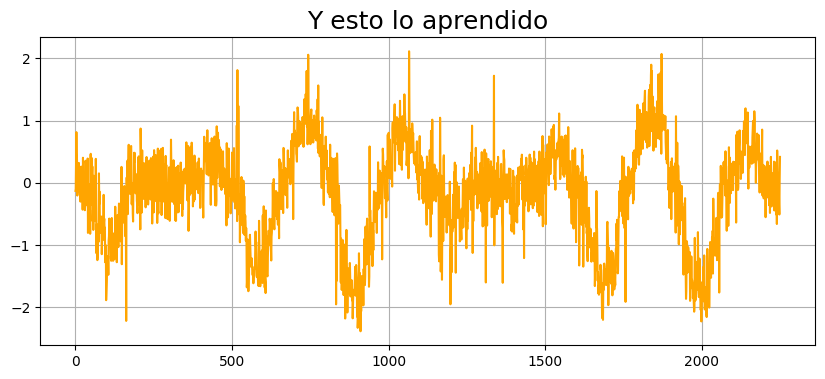

In [25]:
plt.figure(figsize=(10,4))
plt.title("Y esto lo aprendido",fontsize=18)
plt.plot(testPredict,c='orange')
plt.grid(True)
plt.show()

### Comparando con el la verdad conocida (_ground truth_)

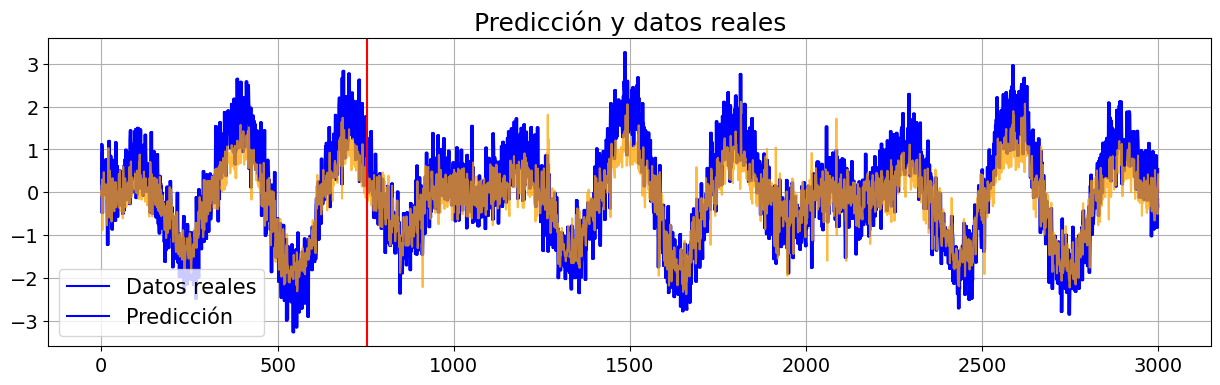

In [26]:
index = df2.index.values
plt.figure(figsize=(15,4))
plt.title("Predicción y datos reales",fontsize=18)
plt.plot(index,df2,c='blue')
plt.plot(index,predicted,c='orange',alpha=0.75)
plt.legend(['Datos reales','Predicción'],fontsize=15)
plt.axvline(df.index[Tp], c="r")
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

### ¿Cómo se distribuyen los errores?

Los errores, o residuos, como se denominan en un problema de regresión, pueden representarse gráficamente para ver si siguen alguna distribución específica. En el proceso de generación, inyectamos ruido gaussiano, por lo que esperamos que el error siga el mismo patrón, _si el modelo ha sido capaz de ajustarse a los datos reales correctamente_.

Si encontramos patrones raros en los residuos es porque el modelo no se ha ajustado
bien a los datos. Habría que probar otras configuraciones/modelos.

In [27]:
error = predicted[Tp:N]-df2[Tp:N]
# Ravel elimina una dimension, lo aplana todo. Como flatten
error = np.array(error).ravel()

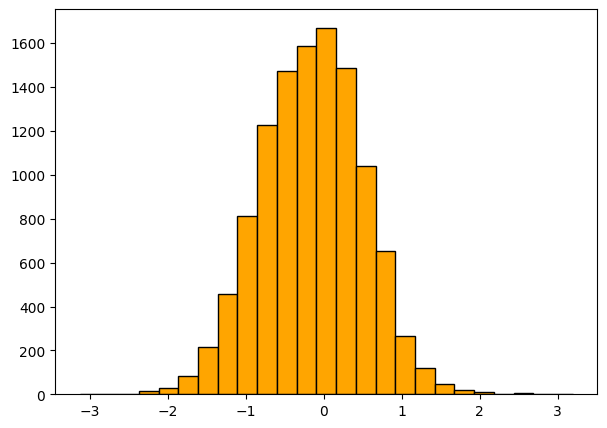

In [28]:
plt.figure(figsize=(7,5))
plt.hist(error,bins=25,edgecolor='k',color='orange')
plt.show()

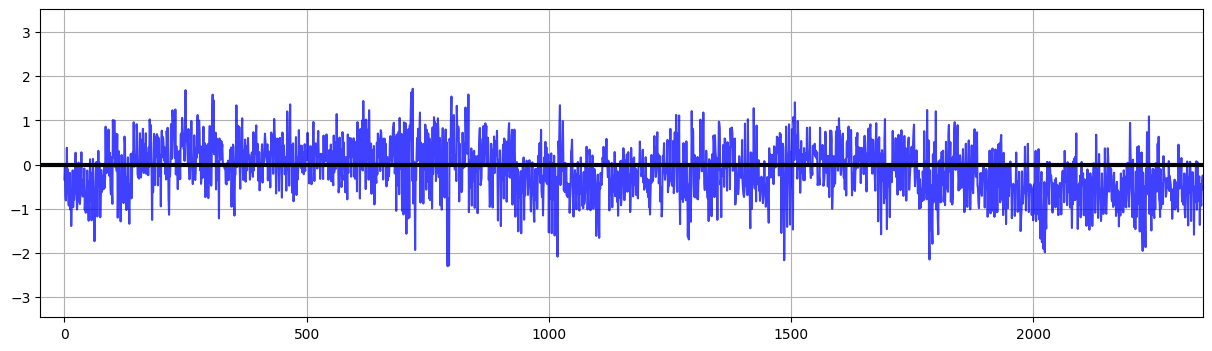

In [29]:
plt.figure(figsize=(15,4))
plt.plot(error,c='blue',alpha=0.75)
plt.hlines(y=0,xmin=-50,xmax=2400,color='k',lw=3)
plt.xlim(-50,2350)
plt.grid(True);

## Mejorando el modelo

Tened en cuenta que, para que estos experimentos sean razonablemente rápidos, fijaremos el tamaño del modelo para que sea más pequeño que el modelo anterior. Utilizaremos una capa RNN de 32 neuronas seguida de una capa densamente conectada de 8 neuronas.

### Variando el embedding/step size

In [30]:
def predictions(model,trainX,testX):
    """Función que concatena las predicciones sobre entrenamiento y evaluación

    Args:
        model (Keras): Modelo
        trainX (Array): Datos de entrenamiento
        testX (Array): Datos de evaluación

    Returns:
        Array: predicciones concatenadas
    """

    trainPredict = model.predict(trainX)
    testPredict = model.predict(testX)
    predicted = np.concatenate((trainPredict,testPredict),axis=0)
    
    return predicted

In [31]:
def plot_compare(predicted, df2):
    """
    Dibuja la comparativa entre dato real y predicho
    """
    index = df2.index.values
    plt.figure(figsize=(15,4))
    plt.title("Predicción y datos reales",fontsize=18)
    plt.plot(index,df2,c='blue')
    plt.plot(index,predicted,c='orange',alpha=0.75)
    plt.legend(['Datos reales','Predicción'],fontsize=15)
    plt.axvline(df2.index[Tp], c="r")
    plt.grid(True)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

In [32]:
def prepare_data(step=4):
    """
    Preparamos los datos con el paso indicado
    """
    df2 = df.copy()
    emb_size = step
    for i in range(1, emb_size+1):
        df2['lag' + str(i)] = df2['Data'].shift(i)

    df2.dropna(inplace=True)
    df2.reset_index(drop=True, inplace=True)

    values = df2.values

    trainX,trainY = values[0:Tp-emb_size ,1:],values[0:Tp-emb_size ,0],
    testX,testY = values[Tp-emb_size:N-emb_size,1:], values[Tp-emb_size:N-emb_size,0]
    
    trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
    testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
    
    return trainX,testX,trainY,testY,df2

In [33]:
from sklearn.metrics import mean_absolute_error

def errors(testX, testY):
    """
    Cálculo del error
    """
    y_true = testY
    y_pred = model.predict(testX)
    return mean_absolute_error(y_true=y_true, y_pred=y_pred)

Parece que cuanto mayor es la ventana, peor le está viniendo al modelo y más ruido le mete.

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Tamaño del embedding: 2
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MAE: 0.4670289608549704
----------------------------------------------------------------------------------------------------


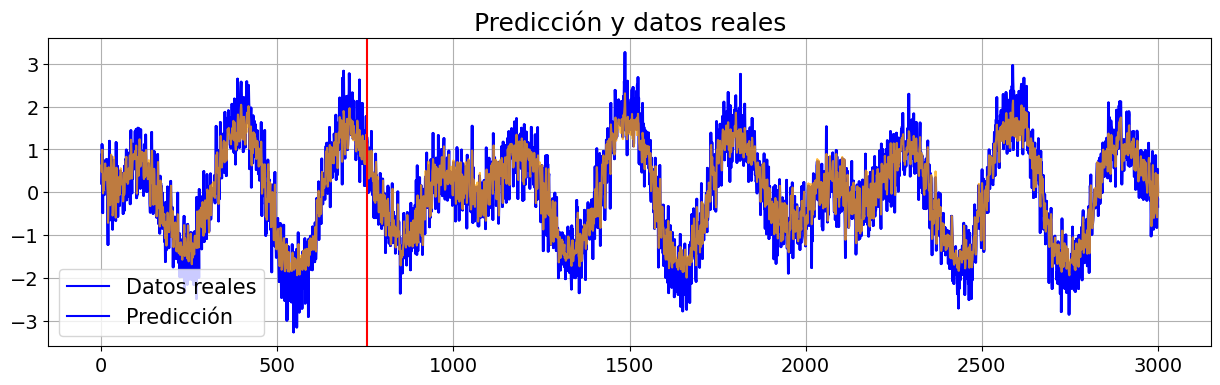

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Tamaño del embedding: 4
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.4319566075095029
----------------------------------------------------------------------------------------------------


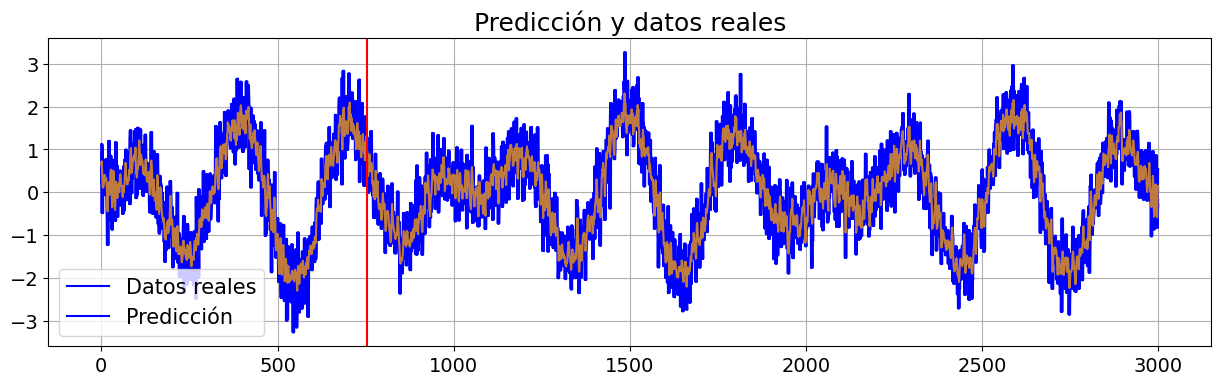

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Tamaño del embedding: 6
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.42863396064136505
----------------------------------------------------------------------------------------------------


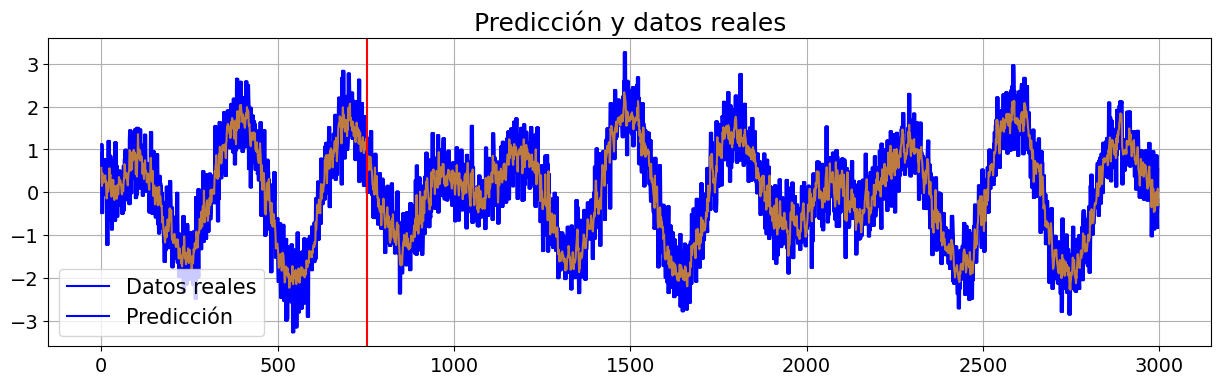

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Tamaño del embedding: 8
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.43087290780209625
----------------------------------------------------------------------------------------------------


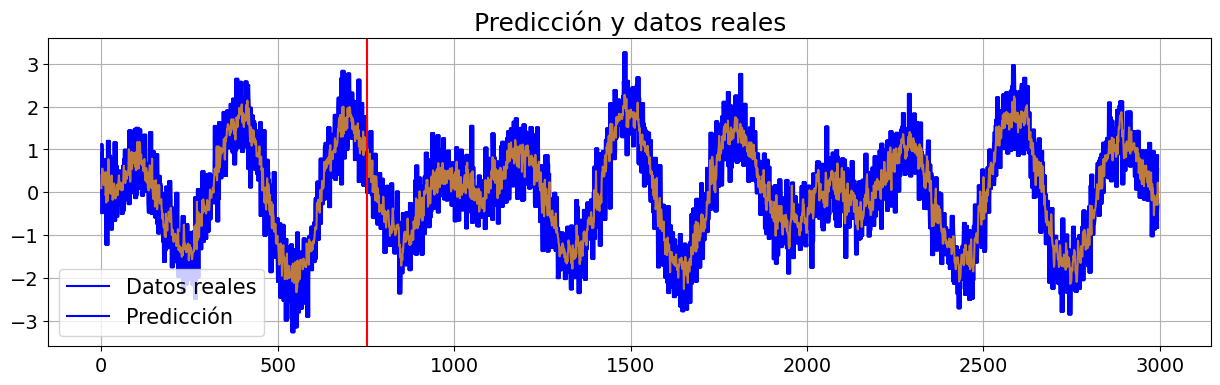

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Tamaño del embedding: 10
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.4371818079301877
----------------------------------------------------------------------------------------------------


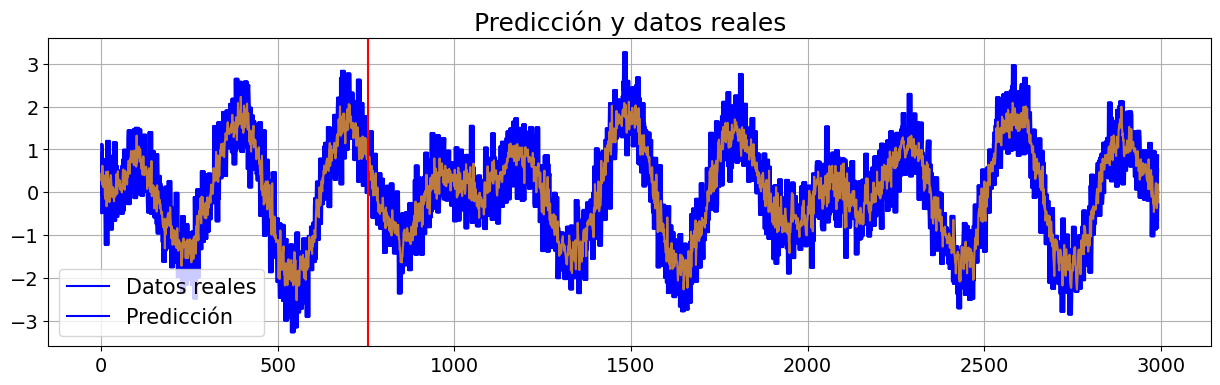

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Tamaño del embedding: 12
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.43036520164998576
----------------------------------------------------------------------------------------------------


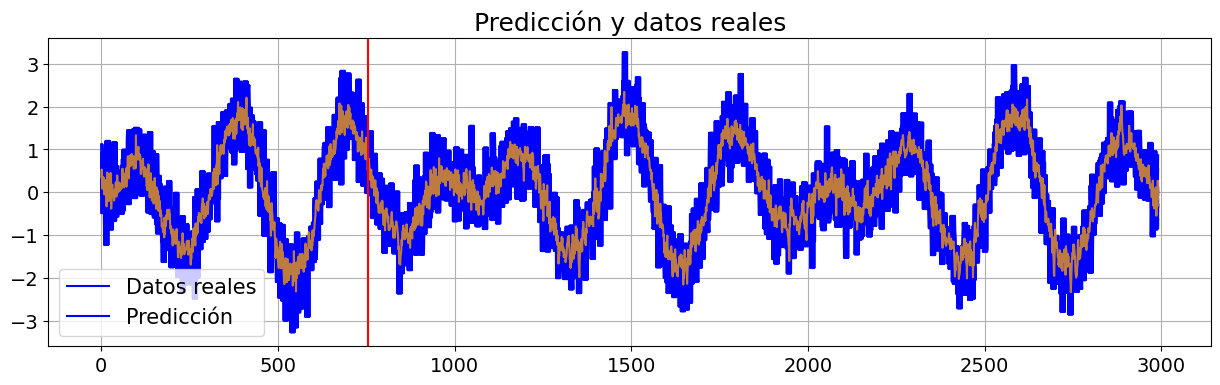

In [34]:
for s in [2,4,6,8,10,12]:
    trainX,testX,trainY,testY,df2 = prepare_data(s)
    model = rnn_simple(num_units=32,num_dense=8,embedding=s)
    batch_size=16
    num_epochs = 100
    model.fit(trainX,trainY, 
          epochs=num_epochs, 
          batch_size=batch_size,
          verbose=0)
    preds = predictions(model,trainX,testX)
    print("Tamaño del embedding: {}".format(s))
    print("MAE:", errors(testX, testY))
    print("-"*100)
    plot_compare(preds, df2)
    print()

### Número de épocas

Probemos ahora con una ventana grande (8), y unas cuantas epochs mas.

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Ran for 100 epochs
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE: 0.4291084451875252
----------------------------------------------------------------------------------------------------


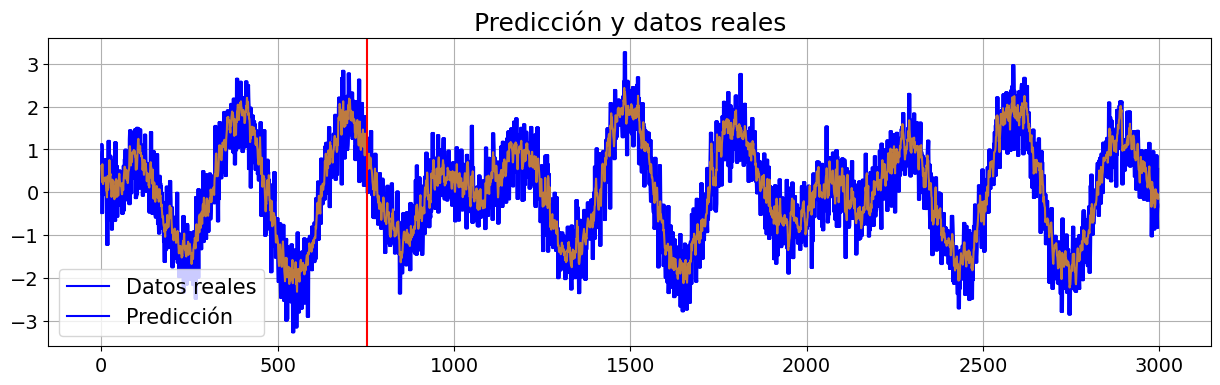

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Ran for 200 epochs
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.4291670703353723
----------------------------------------------------------------------------------------------------


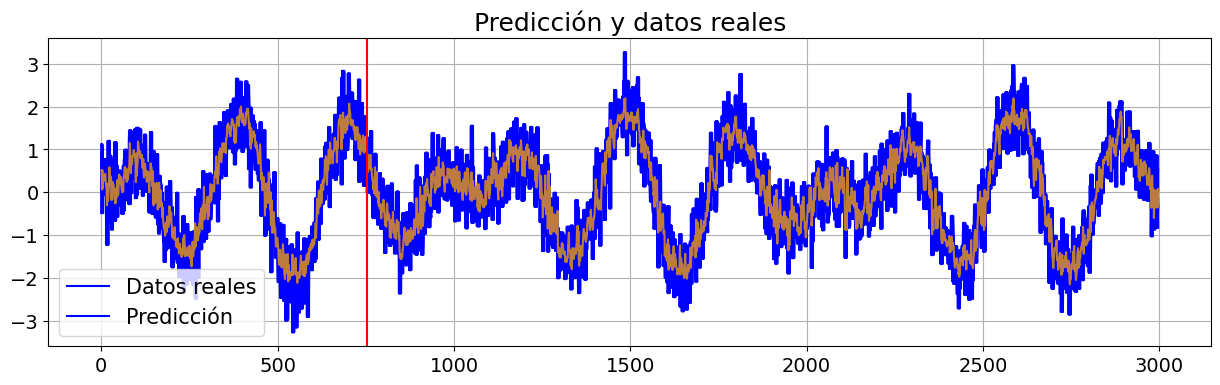

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Ran for 300 epochs
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 0.4504427364681
----------------------------------------------------------------------------------------------------


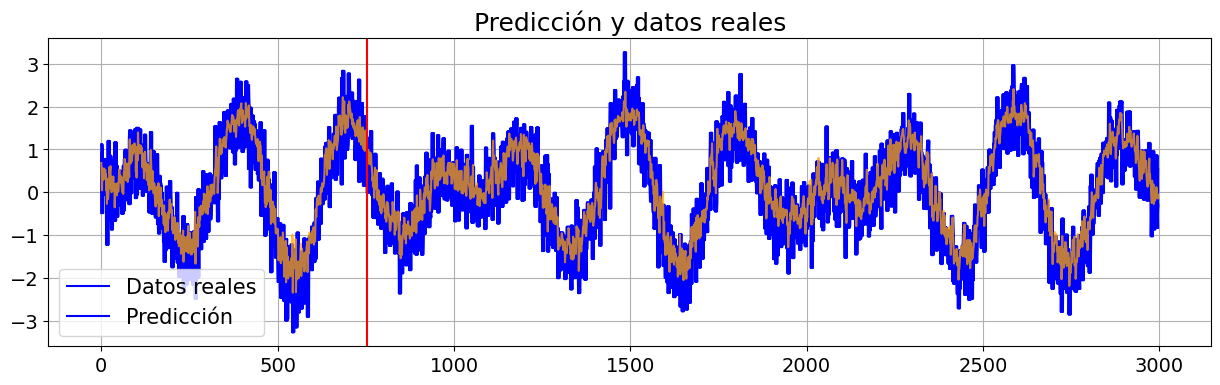

/opt/homebrew/Caskroom/miniforge/base/envs/dl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
for e in [100,200,300,400,500]:
    trainX, testX, trainY, testY, df2 = prepare_data(6)
    model = rnn_simple(num_units=32,num_dense=8,embedding=6)
    batch_size=16
    num_epochs = e
    model.fit(trainX,trainY, 
          epochs=e, 
          batch_size=batch_size,
          verbose=0)
    preds = predictions(model,trainX,testX)
    print("Ran for {} epochs".format(e))
    print("MAE:", errors(testX, testY))
    print("-"*100)
    plot_compare(preds, df2)
    print()

### Batch size

In [ ]:
for b in [4,8,16,32,64]:
    trainX,testX,trainY,testY, df2 = prepare_data(6)
    model = rnn_simple(num_units=32,num_dense=8,embedding=6)
    batch_size=b
    num_epochs = 250
    model.fit(trainX,trainY, 
          epochs=num_epochs, 
          batch_size=b,
          verbose=0)
    preds = predictions(model,trainX,testX)
    print("Batch size: {}".format(b))
    print("MAE:", errors(testX, testY))
    print("-"*100)
    plot_compare(preds, df2)
    print()

### Resumen

Claramente, se observaron las siguientes tendencias,

- Un tamaño de embedding demasiado pequeño no es útil, pero una embedding muy larga tampoco es eficaz. Un embedding de 8 parece buena para estos datos.
- Un mayor número de épocas no siempre es mejor. Probablemente estamos sufriendo sobreajuste
- Un tamaño de lote de 32 o 64 parece óptimo.

En última instancia, es necesario un ajuste exhaustivo de los hiperparámetros para obtener el mejor rendimiento global.

Referencias:
* LSTM https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/